<a href="https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-20-evaluation-of-language-models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 20. Evaluation of Language Models

This lab accompanies **Chapter 20: Evaluation of Language Models** in *The Mathematics of Natural Language Processing*.

Evaluation is not only a collection of scores. It is a mathematical design problem:

$$
\text{model} \longrightarrow \text{predictions} \longrightarrow \text{loss or score} \longrightarrow \text{statistical estimate}.
$$

In this lab, you will build an evaluation toolkit from scratch. The goal is to understand what common NLP metrics compute, when they are useful, and where they can fail.

## Learning goals

By the end of this lab, you should be able to:

1. compute classification metrics from confusion counts;
2. compare thresholds using precision, recall, and $F_1$;
3. compute multiclass macro, micro, and weighted metrics;
4. compute token-level cross-entropy and perplexity;
5. evaluate calibration using Brier score and expected calibration error;
6. implement simple ROUGE-style and BLEU-style overlap metrics;
7. compute retrieval metrics such as Precision@$k$, Recall@$k$, MRR, and nDCG;
8. quantify uncertainty using bootstrap confidence intervals;
9. write a short evaluation report that separates numerical scores from qualitative failure analysis.

## Colab notes

This notebook uses only standard scientific Python tools available in Google Colab: `numpy`, `pandas`, `matplotlib`, and optionally `plotly`.


## 1. Setup

We will use small synthetic NLP-style examples. This keeps the lab transparent: every number can be inspected by hand.


In [1]:
import math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7243)
np.set_printoptions(precision=4, suppress=True)

print("Setup complete.")


Setup complete.


## 2. Evaluation as empirical risk

Let $(X,Y)$ be a random input-output pair from an unknown population distribution $P$.
A model $f_\theta$ is evaluated using a loss function $L$.
The population risk is

$$
R(\theta) = E_P[L(f_\theta(X),Y)].
$$

Since we do not know $P$, we estimate the risk on a finite test set:

$$
\widehat R(\theta)=\frac{1}{n}\sum_{i=1}^n L(f_\theta(x_i),y_i).
$$

Different NLP tasks use different losses and scores, but most of them are still empirical averages or functions of empirical counts.


In [2]:
# A tiny set of item-level losses for a hypothetical model.
losses = np.array([0.12, 0.36, 0.05, 0.80, 0.22, 0.14, 0.43, 0.19])
empirical_risk = losses.mean()

print("Item-level losses:", losses)
print("Empirical risk:", round(empirical_risk, 4))


Item-level losses: [0.12 0.36 0.05 0.8  0.22 0.14 0.43 0.19]
Empirical risk: 0.2888


## 3. Binary classification metrics from scratch

For a binary text classifier, each example has a true label $y_i \in \{0,1\}$ and a predicted probability score $p_i$.
A threshold $\tau$ converts probabilities into hard predictions:

$$
\hat y_i = \mathbf 1\{p_i \ge \tau\}.
$$

From these predictions, we compute the confusion counts:

$$
TP,\ FP,\ FN,\ TN.
$$

Then

$$
\text{Precision}=\frac{TP}{TP+FP}, \qquad
\text{Recall}=\frac{TP}{TP+FN},
$$

and

$$
F_1=\frac{2\cdot \text{Precision}\cdot \text{Recall}}{\text{Precision}+\text{Recall}}.
$$


In [3]:
# Example: a tiny sentiment-like classifier.
y_true = np.array([1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0])
p_score = np.array([0.94, 0.82, 0.76, 0.68, 0.62, 0.49, 0.47, 0.38, 0.31, 0.21, 0.18, 0.08])


def binary_metrics(y_true, p_score, threshold=0.5):
    y_pred = (p_score >= threshold).astype(int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "threshold": threshold,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

for tau in [0.3, 0.5, 0.7]:
    print(binary_metrics(y_true, p_score, threshold=tau))


{'threshold': 0.3, 'TP': 5, 'FP': 4, 'FN': 1, 'TN': 2, 'accuracy': 0.5833333333333334, 'precision': 0.5555555555555556, 'recall': 0.8333333333333334, 'f1': 0.6666666666666667}
{'threshold': 0.5, 'TP': 3, 'FP': 2, 'FN': 3, 'TN': 4, 'accuracy': 0.5833333333333334, 'precision': 0.6, 'recall': 0.5, 'f1': 0.5454545454545454}
{'threshold': 0.7, 'TP': 2, 'FP': 1, 'FN': 4, 'TN': 5, 'accuracy': 0.5833333333333334, 'precision': 0.6666666666666666, 'recall': 0.3333333333333333, 'f1': 0.4444444444444444}


### Exercise 1

Change the threshold values above. Find one threshold with high precision and one threshold with high recall. Explain why they differ.


## 4. Threshold sweeps

A model with probability scores is not a single hard classifier until we choose a decision threshold. The same model can produce many precision-recall tradeoffs.


In [4]:
thresholds = np.linspace(0.05, 0.95, 91)
rows = [binary_metrics(y_true, p_score, threshold=t) for t in thresholds]
metric_df = pd.DataFrame(rows)
metric_df.head()


,threshold,TP,FP,FN,TN,accuracy,precision,recall,f1
0,0.05,6,6,0,0,0.500000,0.500000,1.0,0.666667
1,0.06,6,6,0,0,0.500000,0.500000,1.0,0.666667
2,0.07,6,6,0,0,0.500000,0.500000,1.0,0.666667
3,0.08,6,6,0,0,0.500000,0.500000,1.0,0.666667
4,0.09,6,5,0,1,0.583333,0.545455,1.0,0.705882


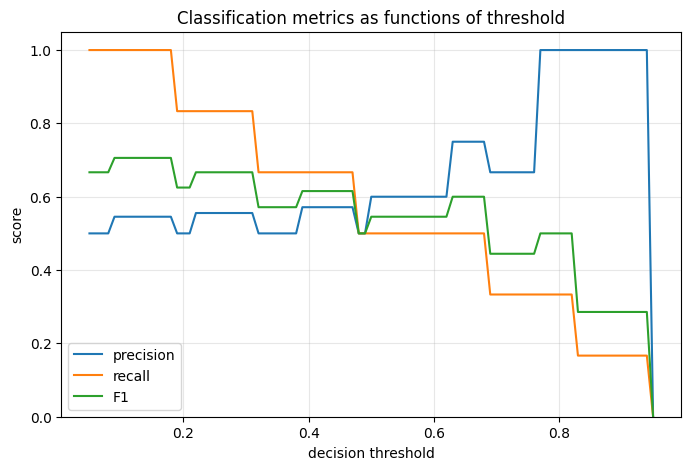

Best F1 threshold in this grid:
threshold    0.090000
precision    0.545455
recall       1.000000
f1           0.705882
Name: 4, dtype: float64


In [5]:
plt.figure(figsize=(8, 5))
plt.plot(metric_df["threshold"], metric_df["precision"], label="precision")
plt.plot(metric_df["threshold"], metric_df["recall"], label="recall")
plt.plot(metric_df["threshold"], metric_df["f1"], label="F1")
plt.xlabel("decision threshold")
plt.ylabel("score")
plt.title("Classification metrics as functions of threshold")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best = metric_df.loc[metric_df["f1"].idxmax()]
print("Best F1 threshold in this grid:")
print(best[["threshold", "precision", "recall", "f1"]])


## 5. Multiclass macro, micro, and weighted $F_1$

In multiclass classification, each class can be treated as positive against all other classes. This gives a per-class $F_1$ score.

Three common averages are:

- **macro average:** equal weight per class;
- **weighted average:** weight each class by its support;
- **micro average:** pool all counts before computing the score.

For single-label multiclass classification, micro $F_1$ equals accuracy.


In [6]:
y_true_mc = np.array([
    "math", "math", "math", "stats", "stats", "stats", "cs", "cs", "cs", "cs", "math", "stats"
])
y_pred_mc = np.array([
    "math", "stats", "math", "stats", "cs", "stats", "cs", "math", "cs", "cs", "math", "cs"
])
classes = sorted(set(y_true_mc) | set(y_pred_mc))


def per_class_metrics(y_true, y_pred, classes):
    rows = []
    for c in classes:
        tp = int(np.sum((y_true == c) & (y_pred == c)))
        fp = int(np.sum((y_true != c) & (y_pred == c)))
        fn = int(np.sum((y_true == c) & (y_pred != c)))
        tn = int(np.sum((y_true != c) & (y_pred != c)))
        precision = tp / (tp + fp) if tp + fp > 0 else 0.0
        recall = tp / (tp + fn) if tp + fn > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
        support = int(np.sum(y_true == c))
        rows.append({
            "class": c, "support": support,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "precision": precision, "recall": recall, "f1": f1,
        })
    return pd.DataFrame(rows)

mc_df = per_class_metrics(y_true_mc, y_pred_mc, classes)
macro_f1 = mc_df["f1"].mean()
weighted_f1 = np.average(mc_df["f1"], weights=mc_df["support"])
accuracy_mc = np.mean(y_true_mc == y_pred_mc)

print(mc_df)
print("macro F1:", round(macro_f1, 4))
print("weighted F1:", round(weighted_f1, 4))
print("micro F1 / accuracy:", round(accuracy_mc, 4))


   class  support  TP  FP  FN  TN  precision  recall        f1
0     cs        4   3   2   1   6   0.600000    0.75  0.666667
1   math        4   3   1   1   7   0.750000    0.75  0.750000
2  stats        4   2   1   2   7   0.666667    0.50  0.571429
macro F1: 0.6627
weighted F1: 0.6627
micro F1 / accuracy: 0.6667


### Exercise 2

Modify `y_pred_mc` to make the minority class worse. Compare macro $F_1$ and weighted $F_1$. Which metric notices the failure more strongly?


## 6. Cross-entropy and perplexity

For an autoregressive language model,

$$
p_\theta(w_{1:T})=\prod_{t=1}^T p_\theta(w_t \mid w_{<t}).
$$

The average negative log-likelihood per target token is

$$
\widehat H=-\frac{1}{N}\sum_{i=1}^N \log p_\theta(w_i\mid \text{context}_i).
$$

When natural logarithms are used, perplexity is

$$
\operatorname{PPL}=\exp(\widehat H).
$$

Perplexity is useful, but it is not automatically comparable across different tokenizers or different evaluation distributions.


In [7]:
def log_softmax(z, axis=-1):
    z = np.asarray(z)
    z_shift = z - np.max(z, axis=axis, keepdims=True)
    return z_shift - np.log(np.sum(np.exp(z_shift), axis=axis, keepdims=True))


def cross_entropy_from_logits(logits, targets, mask=None):
    log_probs = log_softmax(logits, axis=-1)
    token_nll = -log_probs[np.arange(len(targets)), targets]
    if mask is None:
        mask = np.ones_like(token_nll, dtype=float)
    else:
        mask = mask.astype(float)
    mean_nll = np.sum(token_nll * mask) / np.sum(mask)
    ppl = np.exp(mean_nll)
    return mean_nll, ppl, token_nll

# Rows are token positions; columns are vocabulary items.
logits = np.array([
    [2.5, 0.5, 0.1, -0.2],
    [0.2, 2.1, 0.3, 0.0],
    [0.0, 0.1, 2.2, 0.5],
    [1.3, 0.4, 0.2, 1.0],
    [0.5, 0.8, 0.4, 2.0],
])
targets = np.array([0, 1, 2, 3, 3])

mean_nll, ppl, token_nll = cross_entropy_from_logits(logits, targets)
print("token NLL:", np.round(token_nll, 4))
print("mean cross-entropy:", round(mean_nll, 4))
print("perplexity:", round(ppl, 4))


token NLL: [0.2572 0.3628 0.3478 1.2084 0.5459]
mean cross-entropy: 0.5444
perplexity: 1.7236


In [8]:
# Padding masks matter when batches contain variable-length sequences.
# Here the last two positions are padding and should not be scored.
mask = np.array([1, 1, 1, 0, 0])
masked_nll, masked_ppl, _ = cross_entropy_from_logits(logits, targets, mask=mask)

print("unmasked PPL:", round(ppl, 4))
print("masked PPL:", round(masked_ppl, 4))


unmasked PPL: 1.7236
masked PPL: 1.3807


### Exercise 3

Change one logit row so that the model assigns very low probability to the correct token. What happens to cross-entropy and perplexity?


## 7. Calibration: probabilistic honesty

Accuracy asks whether predictions are correct. Calibration asks whether probabilities mean what they claim.

A binary classifier is calibrated if

$$
P(Y=1 \mid \hat p(X)=q)=q.
$$

In practice, we bin predicted probabilities and compare the average confidence in each bin with the empirical positive rate.

The expected calibration error is approximately

$$
\operatorname{ECE}=\sum_{m=1}^M \frac{|B_m|}{n}\left|\operatorname{acc}(B_m)-\operatorname{conf}(B_m)ight|.
$$

The Brier score is

$$
\operatorname{Brier}=\frac{1}{n}\sum_{i=1}^n(\hat p_i-y_i)^2.
$$


In [9]:
def calibration_table(y, p, bins=5):
    y = np.asarray(y)
    p = np.asarray(p)
    edges = np.linspace(0, 1, bins + 1)
    rows = []
    ece = 0.0
    for j in range(bins):
        lo, hi = edges[j], edges[j + 1]
        if j == bins - 1:
            mask = (p >= lo) & (p <= hi)
        else:
            mask = (p >= lo) & (p < hi)
        count = int(np.sum(mask))
        if count == 0:
            continue
        conf = float(np.mean(p[mask]))
        acc = float(np.mean(y[mask]))
        weight = count / len(y)
        ece += weight * abs(acc - conf)
        rows.append({"bin_low": lo, "bin_high": hi, "count": count, "confidence": conf, "accuracy": acc})
    brier = float(np.mean((p - y) ** 2))
    return pd.DataFrame(rows), ece, brier

cal_df, ece, brier = calibration_table(y_true, p_score, bins=4)
print(cal_df)
print("ECE:", round(ece, 4))
print("Brier:", round(brier, 4))


   bin_low  bin_high  count  confidence  accuracy
0     0.00      0.25      3    0.156667  0.333333
1     0.25      0.50      4    0.412500  0.500000
2     0.50      0.75      2    0.650000  0.500000
3     0.75      1.00      3    0.840000  0.666667
ECE: 0.1417
Brier: 0.2471


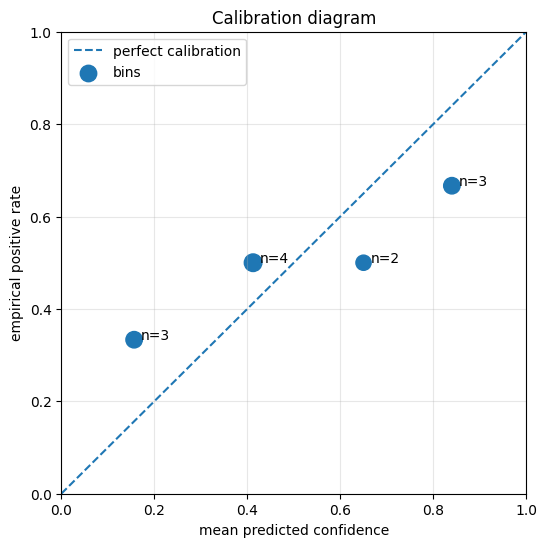

In [10]:
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="perfect calibration")
plt.scatter(cal_df["confidence"], cal_df["accuracy"], s=80 + 20 * cal_df["count"], label="bins")
for _, row in cal_df.iterrows():
    plt.text(row["confidence"] + 0.015, row["accuracy"], f"n={int(row['count'])}")
plt.xlabel("mean predicted confidence")
plt.ylabel("empirical positive rate")
plt.title("Calibration diagram")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Optional: temperature scaling

Temperature scaling rescales logits before applying a sigmoid or softmax. For binary probabilities, if $z=\log(p/(1-p))$, then

$$
p_T = \sigma(z/T).
$$

Larger $T$ pushes probabilities toward $0.5$; smaller $T$ makes probabilities more extreme.


In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def logit(p):
    p = np.clip(p, 1e-8, 1 - 1e-8)
    return np.log(p / (1 - p))

for T in [0.5, 1.0, 2.0, 4.0]:
    p_temp = sigmoid(logit(p_score) / T)
    _, ece_temp, brier_temp = calibration_table(y_true, p_temp, bins=4)
    print(f"T={T:>3}: mean confidence={p_temp.mean():.3f}, ECE={ece_temp:.3f}, Brier={brier_temp:.3f}")


T=0.5: mean confidence=0.490, ECE=0.276, Brier=0.301
T=1.0: mean confidence=0.495, ECE=0.142, Brier=0.247
T=2.0: mean confidence=0.498, ECE=0.119, Brier=0.227
T=4.0: mean confidence=0.500, ECE=0.015, Brier=0.231


## 8. Overlap metrics for generated text

For generation tasks, there may be many valid answers. Overlap metrics are imperfect but useful as quick baselines.

For a generated sequence $G$ and reference sequence $R$, clipped $n$-gram precision is

$$
P_n=\frac{\sum_g \min\{c_G(g),c_R(g)\}}{\sum_g c_G(g)}.
$$

A simple ROUGE-1 recall score is

$$
\operatorname{ROUGE\text{-}1} = \frac{\text{overlapping reference unigrams}}{\text{reference unigrams}}.
$$

A simplified BLEU-like score combines clipped precisions with a brevity penalty.


In [12]:
def tokenize_simple(text):
    text = text.lower()
    for ch in ".,;:!?()[]{}":
        text = text.replace(ch, " ")
    return text.split()


def ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]


def clipped_precision(generated_tokens, reference_tokens, n):
    g_counts = Counter(ngrams(generated_tokens, n))
    r_counts = Counter(ngrams(reference_tokens, n))
    overlap = sum(min(count, r_counts[gram]) for gram, count in g_counts.items())
    total = sum(g_counts.values())
    return overlap / total if total > 0 else 0.0


def rouge1_recall(generated_tokens, reference_tokens):
    g_counts = Counter(generated_tokens)
    r_counts = Counter(reference_tokens)
    overlap = sum(min(g_counts[token], count) for token, count in r_counts.items())
    total = sum(r_counts.values())
    return overlap / total if total > 0 else 0.0


def bleu_like(generated_tokens, reference_tokens, max_n=2, eps=1e-12):
    precisions = [max(clipped_precision(generated_tokens, reference_tokens, n), eps) for n in range(1, max_n + 1)]
    geo_mean = math.exp(sum(math.log(p) for p in precisions) / max_n)
    bp = 1.0 if len(generated_tokens) > len(reference_tokens) else math.exp(1 - len(reference_tokens) / max(len(generated_tokens), 1))
    return bp * geo_mean

reference = tokenize_simple("the model retrieves relevant evidence before answering the question")
generated_good = tokenize_simple("the system retrieves relevant evidence before answering")
generated_bad = tokenize_simple("the answer sounds fluent but ignores the evidence")

for name, generated in [("good", generated_good), ("bad", generated_bad)]:
    print(name)
    print("  unigram precision:", round(clipped_precision(generated, reference, 1), 4))
    print("  bigram precision:", round(clipped_precision(generated, reference, 2), 4))
    print("  ROUGE-1 recall:", round(rouge1_recall(generated, reference), 4))
    print("  BLEU-like:", round(bleu_like(generated, reference, max_n=2), 4))


good
  unigram precision: 0.8571
  bigram precision: 0.6667
  ROUGE-1 recall: 0.6667
  BLEU-like: 0.5681
bad
  unigram precision: 0.375
  bigram precision: 0.0
  ROUGE-1 recall: 0.3333
  BLEU-like: 0.0


### Exercise 4

Create a generated answer that has high unigram overlap but is semantically wrong. This illustrates why overlap is not the same as correctness.


## 9. Retrieval and RAG evaluation

For retrieval, the system returns an ordered list of documents:

$$
(d_1,d_2,\ldots,d_k).
$$

Let $R(q)$ be the set of relevant documents for query $q$. Then

$$
\operatorname{Precision@}k=\frac{|\{d_1,\ldots,d_k\}\cap R(q)|}{k},
$$

and

$$
\operatorname{Recall@}k=\frac{|\{d_1,\ldots,d_k\}\cap R(q)|}{|R(q)|}.
$$

Mean reciprocal rank measures how early the first relevant document appears.
For graded relevance, nDCG rewards placing highly relevant documents near the top.


In [13]:
def precision_at_k(ranked, relevant, k):
    top = ranked[:k]
    return len(set(top) & set(relevant)) / k


def recall_at_k(ranked, relevant, k):
    top = ranked[:k]
    return len(set(top) & set(relevant)) / len(relevant) if relevant else 0.0


def reciprocal_rank(ranked, relevant):
    relevant = set(relevant)
    for i, doc in enumerate(ranked, start=1):
        if doc in relevant:
            return 1 / i
    return 0.0


def dcg_at_k(relevances, k):
    return sum((2 ** rel - 1) / math.log2(i + 2) for i, rel in enumerate(relevances[:k]))


def ndcg_at_k(ranked_relevances, k):
    dcg = dcg_at_k(ranked_relevances, k)
    ideal = dcg_at_k(sorted(ranked_relevances, reverse=True), k)
    return dcg / ideal if ideal > 0 else 0.0

ranked_docs = ["d7", "d2", "d9", "d1", "d4"]
relevant_docs = {"d1", "d2", "d4"}
ranked_relevances = [0, 2, 0, 3, 1]

print("Precision@3:", precision_at_k(ranked_docs, relevant_docs, 3))
print("Recall@3:", recall_at_k(ranked_docs, relevant_docs, 3))
print("RR:", reciprocal_rank(ranked_docs, relevant_docs))
print("nDCG@5:", ndcg_at_k(ranked_relevances, 5))


Precision@3: 0.3333333333333333
Recall@3: 0.3333333333333333
RR: 0.5
nDCG@5: 0.5636640860885236


In [14]:
# Multiple-query retrieval evaluation.
retrieval_examples = [
    {"query": "define perplexity", "ranked": ["d1", "d3", "d2", "d5"], "relevant": {"d1", "d2"}},
    {"query": "calibration error", "ranked": ["d4", "d6", "d2", "d1"], "relevant": {"d4"}},
    {"query": "RAG retrieval metrics", "ranked": ["d8", "d9", "d7", "d1"], "relevant": {"d7", "d8"}},
]

rows = []
for ex in retrieval_examples:
    rows.append({
        "query": ex["query"],
        "P@2": precision_at_k(ex["ranked"], ex["relevant"], 2),
        "R@2": recall_at_k(ex["ranked"], ex["relevant"], 2),
        "RR": reciprocal_rank(ex["ranked"], ex["relevant"]),
    })
retrieval_df = pd.DataFrame(rows)
print(retrieval_df)
print("Mean P@2:", round(retrieval_df["P@2"].mean(), 4))
print("Mean R@2:", round(retrieval_df["R@2"].mean(), 4))
print("MRR:", round(retrieval_df["RR"].mean(), 4))


                   query  P@2  R@2   RR
0      define perplexity  0.5  0.5  1.0
1      calibration error  0.5  1.0  1.0
2  RAG retrieval metrics  0.5  0.5  1.0
Mean P@2: 0.5
Mean R@2: 0.6667
MRR: 1.0


### RAG decomposition

A RAG system should be evaluated in stages:

$$
\text{RAG quality} = \text{retrieval quality} + \text{grounding quality} + \text{answer quality}.
$$

A high-quality answer is not enough if the citation is unsupported. A good retrieval score is not enough if the generator ignores the retrieved evidence.


In [15]:
rag_cases = pd.DataFrame([
    {"query": "What is perplexity?", "retrieved_relevant": 1, "answer_supported": 1, "answer_correct": 1},
    {"query": "What is ECE?", "retrieved_relevant": 1, "answer_supported": 0, "answer_correct": 0},
    {"query": "Explain nDCG", "retrieved_relevant": 0, "answer_supported": 0, "answer_correct": 0},
    {"query": "Define macro F1", "retrieved_relevant": 1, "answer_supported": 1, "answer_correct": 0},
])

print(rag_cases)
print("retrieval success rate:", rag_cases["retrieved_relevant"].mean())
print("grounding success rate:", rag_cases["answer_supported"].mean())
print("answer correctness rate:", rag_cases["answer_correct"].mean())


                 query  retrieved_relevant  answer_supported  answer_correct
0  What is perplexity?                   1                 1               1
1         What is ECE?                   1                 0               0
2         Explain nDCG                   0                 0               0
3      Define macro F1                   1                 1               0
retrieval success rate: 0.75
grounding success rate: 0.5
answer correctness rate: 0.25


## 10. Bootstrap uncertainty

A reported metric is computed on a finite sample, so it has uncertainty.
For complicated metrics such as $F_1$, a bootstrap interval is often easier than deriving a formula.

The nonparametric bootstrap repeatedly samples test examples with replacement and recomputes the metric.


In [16]:
def f1_from_labels(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    precision = tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = tp / (tp + fn) if tp + fn > 0 else 0.0
    return 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0


def bootstrap_ci_metric(y_true, p_score, metric_fn, threshold=0.5, B=2000, seed=2026):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    values = []
    for _ in range(B):
        idx = rng.choice(n, size=n, replace=True)
        y_b = y_true[idx]
        p_b = p_score[idx]
        y_pred_b = (p_b >= threshold).astype(int)
        values.append(metric_fn(y_b, y_pred_b))
    return np.quantile(values, [0.025, 0.975]), np.array(values)

y_pred_05 = (p_score >= 0.5).astype(int)
f1_hat = f1_from_labels(y_true, y_pred_05)
ci, boot_values = bootstrap_ci_metric(y_true, p_score, f1_from_labels, threshold=0.5, B=2000)

print("F1 at threshold 0.5:", round(f1_hat, 4))
print("bootstrap 95% CI:", np.round(ci, 4))


F1 at threshold 0.5: 0.5455
bootstrap 95% CI: [0.     0.8339]


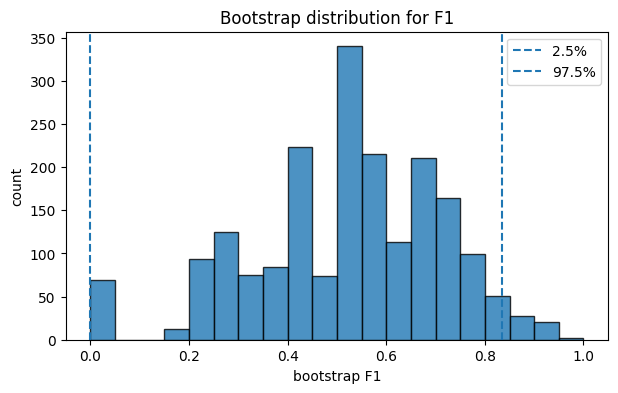

In [17]:
plt.figure(figsize=(7, 4))
plt.hist(boot_values, bins=20, edgecolor="black", alpha=0.8)
plt.axvline(ci[0], linestyle="--", label="2.5%")
plt.axvline(ci[1], linestyle="--", label="97.5%")
plt.xlabel("bootstrap F1")
plt.ylabel("count")
plt.title("Bootstrap distribution for F1")
plt.legend()
plt.show()


### Exercise 5

Increase the number of test examples by simulating 200 examples instead of 12. What happens to the width of the bootstrap interval?


## 11. Comparing two models with paired differences

If two systems are evaluated on the same examples, use paired comparisons. Let

$$
d_i = L_A(x_i,y_i)-L_B(x_i,y_i).
$$

If lower loss is better, $d_i > 0$ means system B was better on item $i$.
A confidence interval for $\bar d$ shows whether the observed difference is large relative to item-level variability.


Mean paired loss reduction A - B: 0.0301
Approximate 95% CI: (np.float64(0.0124), np.float64(0.0477))


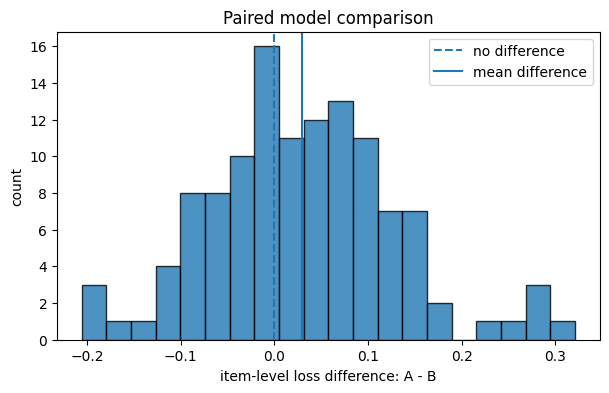

In [18]:
rng = np.random.default_rng(7339)
loss_A = rng.normal(loc=0.52, scale=0.15, size=120)
loss_B = loss_A - rng.normal(loc=0.035, scale=0.09, size=120)
diff = loss_A - loss_B

mean_diff = diff.mean()
se_diff = diff.std(ddof=1) / np.sqrt(len(diff))
ci_diff = (mean_diff - 1.96 * se_diff, mean_diff + 1.96 * se_diff)

print("Mean paired loss reduction A - B:", round(mean_diff, 4))
print("Approximate 95% CI:", tuple(np.round(ci_diff, 4)))

plt.figure(figsize=(7, 4))
plt.hist(diff, bins=20, edgecolor="black", alpha=0.8)
plt.axvline(0, linestyle="--", label="no difference")
plt.axvline(mean_diff, label="mean difference")
plt.xlabel("item-level loss difference: A - B")
plt.ylabel("count")
plt.title("Paired model comparison")
plt.legend()
plt.show()


## 12. Subpopulation analysis and distribution shift

A single average can hide failures. If the data are partitioned into groups $G_1,\ldots,G_m$, compute metrics within each group:

$$
\widehat R_j=\frac{1}{|G_j|}\sum_{i\in G_j}L(f_\theta(x_i),y_i).
$$

This is important for robustness, fairness, and domain adaptation.


     domain  n  accuracy
0     admin  8     0.375
1    course  8     0.875
2  research  8     0.500
overall accuracy: 0.5833333333333334


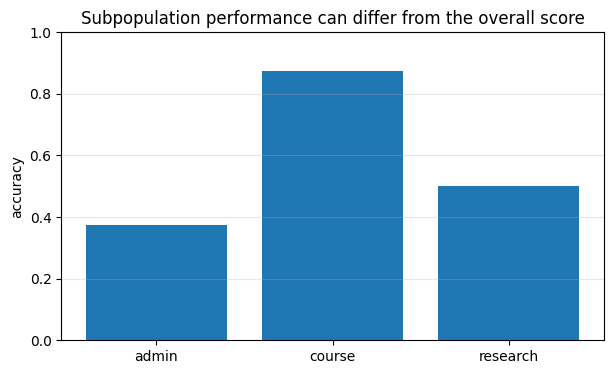

In [19]:
subpop = pd.DataFrame({
    "domain": ["course"] * 8 + ["research"] * 8 + ["admin"] * 8,
    "correct": [1,1,1,1,1,0,1,1, 1,0,1,0,1,0,1,0, 1,1,0,0,0,1,0,0],
})

summary = subpop.groupby("domain").agg(
    n=("correct", "size"),
    accuracy=("correct", "mean"),
).reset_index()
print(summary)
print("overall accuracy:", subpop["correct"].mean())

plt.figure(figsize=(7, 4))
plt.bar(summary["domain"], summary["accuracy"])
plt.ylim(0, 1)
plt.ylabel("accuracy")
plt.title("Subpopulation performance can differ from the overall score")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


### Exercise 6

Add a fourth domain with very few examples. Why should small subgroup scores be interpreted carefully?


## 13. A small evaluation dashboard

The code below creates a compact dashboard table. In Colab, Plotly can make this interactive. If Plotly is unavailable, the notebook still runs and prints the table.


In [20]:
report_rows = []
for tau in [0.3, 0.5, 0.7]:
    report_rows.append(binary_metrics(y_true, p_score, threshold=tau))
report_df = pd.DataFrame(report_rows)
report_df[["threshold", "accuracy", "precision", "recall", "f1"]]


,threshold,accuracy,precision,recall,f1
0,0.3,0.583333,0.555556,0.833333,0.666667
1,0.5,0.583333,0.600000,0.500000,0.545455
2,0.7,0.583333,0.666667,0.333333,0.444444


In [21]:
try:
    import plotly.express as px
    long_df = report_df.melt(
        id_vars="threshold",
        value_vars=["accuracy", "precision", "recall", "f1"],
        var_name="metric",
        value_name="score",
    )
    fig = px.line(long_df, x="threshold", y="score", color="metric", markers=True,
                  title="Evaluation dashboard: threshold tradeoffs")
    fig.update_yaxes(range=[0, 1.05])
    fig.show()
except Exception as e:
    print("Plotly display skipped:", e)
    print(report_df[["threshold", "accuracy", "precision", "recall", "f1"]])


## 14. AI-assisted evaluation rubric

Language models can assist with evaluation, but an AI judge is itself a model. It has biases and failure modes.
For mathematical NLP tasks, use structured rubrics and validate AI judgments against human judgments.

A useful rubric can separate dimensions:

| Dimension | Question |
|---|---|
| Correctness | Are claims mathematically or factually correct? |
| Completeness | Does the answer address all required parts? |
| Grounding | Are claims supported by the provided evidence? |
| Notation | Are symbols and definitions used consistently? |
| Clarity | Is the explanation understandable for the intended audience? |

Example prompt pattern:

```text
You are evaluating an NLP model answer for a graduate applied mathematics audience.
Score the answer from 0 to 4 on: correctness, completeness, grounding, notation, and clarity.
For each score, cite the exact sentence or formula that supports your judgment.
Do not reward fluent but unsupported claims.
```


In [22]:
# A tiny structured rubric example.
rubric_scores = pd.DataFrame([
    {"answer_id": "A", "correctness": 4, "completeness": 3, "grounding": 4, "notation": 4, "clarity": 3},
    {"answer_id": "B", "correctness": 2, "completeness": 3, "grounding": 1, "notation": 3, "clarity": 4},
    {"answer_id": "C", "correctness": 3, "completeness": 2, "grounding": 3, "notation": 2, "clarity": 3},
])
weights = {
    "correctness": 0.35,
    "completeness": 0.20,
    "grounding": 0.25,
    "notation": 0.10,
    "clarity": 0.10,
}

rubric_scores["weighted_score"] = sum(rubric_scores[col] * w for col, w in weights.items())
print(rubric_scores)


  answer_id  correctness  completeness  ...  notation  clarity  weighted_score
0         A            4             3  ...         4        3            3.70
1         B            2             3  ...         3        4            2.25
2         C            3             2  ...         2        3            2.70

[3 rows x 7 columns]


## 15. Mini-project: write an evaluation report

Choose one system from earlier labs:

- a Naive Bayes sentiment classifier;
- a TF-IDF retrieval system;
- an embedding-based retrieval system;
- a small language model;
- a toy RAG prototype.

Write a short evaluation report with the following sections:

1. **Task definition.** What input-output behavior is being evaluated?
2. **Data split.** What are training, validation, and test examples?
3. **Metrics.** Which metrics are used, and why?
4. **Numerical results.** Include a table of scores.
5. **Uncertainty.** Include a confidence interval or bootstrap interval.
6. **Error analysis.** Show at least five qualitative errors.
7. **Limitations.** Explain what the metric does not prove.
8. **Improvement plan.** Suggest one concrete next step.

The key lesson is that a metric is not a property of a model alone. It is a property of the model, data distribution, task definition, annotation procedure, and decision rule.


## 16. Summary

In this lab, you built an evaluation toolkit for NLP systems.

You implemented:

- classification metrics from confusion counts;
- threshold sweeps;
- multiclass $F_1$ averaging;
- cross-entropy and perplexity;
- calibration metrics;
- overlap metrics for generated text;
- retrieval metrics;
- RAG-stage evaluation;
- bootstrap confidence intervals;
- paired model comparisons;
- subgroup analysis;
- a small dashboard and structured rubric.

A mathematically mature evaluation always asks:

> What quantity is this metric estimating, and is that quantity actually what we care about?
